<a href="https://colab.research.google.com/github/kidujm/data_mini_project/blob/main/%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_%EA%B3%B5%ED%86%B5%EC%A7%84%ED%96%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PART 1 실행코드


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro

#1. 데이터 로드 (변수명: df)
df = pd.read_csv('최종분석파일.csv')

In [ ]:
# 2. 로그 변환 변수 생성 (Log1p 사용으로 0값 처리)
log_target_cols = ['월간 검색량', '블로그리뷰수', '방문자리뷰수', '방문자사진수']
for col in log_target_cols:
    df[f'log_{col.replace(" ", "")}'] = np.log1p(df[col])

In [ ]:
# 3. 성과지표 재정의 (파생변수 생성)
# ① 영업기간 통제 성과지표 (기존 데이터 보완)
df['리뷰_월효율'] = df['방문자리뷰수'] / df['영업_개월_수']
df['사진_월효율'] = df['방문자사진수'] / df['영업_개월_수']

# ② 입지 보정 성과지표 (핵심: 유동인구 대비 성과)
# 유동인구 0인 경우 대비 epsilon 처리
df['유동보정_리뷰율'] = (df['방문자리뷰수'] / (df['총유동인구_수'] + 1)) * 10000
df['유동보정_검색율'] = (df['월간 검색량'] / (df['총유동인구_수'] + 1)) * 10000

# ③ 효율 및 비주얼 지표
df['검색_전환_효율'] = df['방문자리뷰수'] / (df['월간 검색량'] + 1)
df['사진_리뷰_비율'] = df['방문자사진수'] / (df['방문자리뷰수'] + 1)

In [ ]:
# 4. 정규성 검정 (Shapiro-Wilk Test)
# 주요 분석 대상 변수들에 대해 수행
check_cols = ['log_월간검색량', 'log_방문자리뷰수', '유동보정_리뷰율', '비주얼_지수']
normality_results = []

for col in check_cols:
    stat, p = shapiro(df[col].dropna())
    normality_results.append({
        'Variable': col,
        'Statistic': stat,
        'p-value': p,
        'Is_Normal': 'Yes' if p > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_results)

In [ ]:
# 5. 결과 출력
print("--- PART 1-2 파생지표 기초통계량 ---")
print(df[['리뷰_월효율', '유동보정_리뷰율', '검색_전환_효율', '사진_리뷰_비율']].describe())
print("\n--- PART 1-1 정규성 검정 결과 ---")
print(normality_df)

--- PART 1-2 파생지표 기초통계량 ---
           리뷰_월효율    유동보정_리뷰율    검색_전환_효율    사진_리뷰_비율
count  576.000000  576.000000  576.000000  576.000000
mean     4.897686    0.700927   12.051753    0.540567
std      5.115322    1.778574   13.323569    2.889981
min      0.000000    0.000000    0.000000    0.000000
25%      1.389907    0.130001    2.988095    0.150388
50%      3.161111    0.313494    7.000000    0.228613
75%      6.881868    0.671596   16.869048    0.459149
max     46.000000   30.481379   83.190476   67.000000

--- PART 1-1 정규성 검정 결과 ---
     Variable  Statistic       p-value Is_Normal
0   log_월간검색량   0.492774  1.736695e-37        No
1  log_방문자리뷰수   0.972466  6.221600e-09        No
2    유동보정_리뷰율   0.298830  5.578871e-42        No
3      비주얼_지수   0.079632  5.846908e-46        No


# PART1 결과 분석 보고
1.정규성 검정 결과 :
- 모든 변수는 정규성 가정을 기각함. 따라서 향후 평균 비교 분석 시 모수 검정(T-test, ANOVA)이 아닌 비모수 검정(Mann-Whitney U test, Kruskal-Wallis test) 수행이 필수적임.

2. 파생지표 기초통계량 특성 :
- 유동보정_리뷰율: 평균($0.70$)과 중앙값($0.31$)의 차이가 크고, 최대값($30.48$)이 75% 지점($0.67$)에 비해 매우 높음. 이는 특정 입지나 브랜드에서 유동인구 대비 압도적인 리뷰 전환율을 보이는 '이상치(Outlier)형 매장'이 존재함을 시사함.
- 검색_전환_효율: 중앙값이 $7.0$인데 반해 평균이 $12.05$로 나타남. 이는 검색량 대비 리뷰 수가 비정상적으로 높은 매장들이 상위 분포를 형성하고 있음을 의미함.


# PART 2 실행코드

PART 2. 브랜드 효과 vs 입지 효과 분리 분석 (재수행)
본 분석은 성과 지표의 차이가 브랜드 자체의 경쟁력(Brand Effect)인지, 혹은 매장이 위치한 입지 조건(Location Effect)에 기인한 것인지 통계적으로 규명하는 것을 목적으로 함. PART 1에서 확인된 바와 같이 모든 지표가 정규성을 만족하지 않으므로, 비모수 검정법을 적용함.

In [ ]:
df[df['brand'].str.contains('역전')]

,brand,시도명,시군구명,행정동_코드,행정동명,법정동명,도로명주소,경도,위도,place_id,...,log_월간검색량,log_블로그리뷰수,log_방문자리뷰수,log_방문자사진수,리뷰_월효율,사진_월효율,유동보정_리뷰율,유동보정_검색율,검색_전환_효율,사진_리뷰_비율
3,역전할머니,서울특별시,강서구,11500591,화곡6동,화곡동,서울특별시 강서구 화곡로58길 22-3,126.852178,37.552714,1868359886,...,3.044522,4.110874,6.418365,4.382027,7.463415,0.963415,1.121319,0.036644,29.142857,0.128874
5,역전할머니,서울특별시,서대문구,11410685,홍은2동,홍은동,서울특별시 서대문구 증가로10길 63,126.925270,37.579687,1323812622,...,3.044522,3.610918,6.047372,4.110874,6.205882,0.882353,0.964523,0.045712,20.095238,0.141844
10,역전할머니,서울특별시,영등포구,11560670,신길5동,신길동,서울특별시 영등포구 신길로 67,126.908128,37.498765,1311695977,...,3.044522,3.583519,5.902633,4.553877,7.300000,1.880000,1.165407,0.063858,17.380952,0.256831
15,역전할머니,서울특별시,중랑구,11260590,상봉2동,상봉동,서울특별시 중랑구 봉우재로33길 42,127.088287,37.594237,1650551571,...,3.044522,4.248495,6.666957,3.806662,14.017857,0.785714,1.051452,0.026789,37.380952,0.055980
16,역전할머니,서울특별시,구로구,11530770,오류1동,오류동,서울특별시 구로구 경인로25길 16,126.844202,37.497175,1404198758,...,3.044522,5.236442,6.052089,4.110874,18.434783,2.608696,1.113247,0.052512,20.190476,0.141176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,역전할머니,경기도,광명시,41210633,하안3동,하안동,경기도 광명시 하안로 293-8,126.879497,37.461735,1535589492,...,3.044522,3.332205,6.519147,4.477337,9.671429,1.242857,0.348990,0.010310,32.238095,0.128319
564,역전할머니,경기도,의왕시,41430540,내손1동,내손동,경기도 의왕시 계원대학로 47,126.976662,37.379765,1891683756,...,3.044522,3.091042,5.762051,3.761200,4.464789,0.591549,0.986403,0.062234,15.095238,0.132075
566,역전할머니,경기도,용인시 처인구,41461510,중앙동,김량장동,경기도 용인시 처인구 금령로 79-4,127.205012,37.235532,1228767540,...,3.044522,2.944439,5.799093,4.406719,4.838235,1.191176,3.433450,0.208720,15.666667,0.245455
567,역전할머니,경기도,고양시 덕양구,41281520,원신동,신원동,경기도 고양시 덕양구 신원로 12-11,126.890880,37.662641,1091472254,...,3.044522,2.708050,5.686975,3.526361,4.388060,0.492537,0.392898,0.026728,14.000000,0.111864


In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu, kruskal

# 1. 브랜드명 변수 설정 (사용자 요청 반영)
brand_a = '투다리'
brand_b = '역전할머니'

# 2. 브랜드 간 성과 차이 검증 (Mann-Whitney U Test)
def compare_brand_fixed(df, target_col):
    group_a = df[df['brand'] == brand_a][target_col].dropna()
    group_b = df[df['brand'] == brand_b][target_col].dropna()

    # 데이터 존재 여부 확인
    if len(group_a) == 0 or len(group_b) == 0:
        return {
            'Variable': target_col,
            '투다리_Median': group_a.median() if len(group_a) > 0 else "No Data",
            '역전할머니_Median': group_b.median() if len(group_b) > 0 else "No Data",
            'p-value': None,
            'Significant': 'Error'
        }

    stat, p = mannwhitneyu(group_a, group_b, alternative='two-sided')

    return {
        'Variable': target_col,
        '투다리_Median': group_a.median(),
        '역전할머니_Median': group_b.median(),
        'p-value': p,
        'Significant': 'Yes' if p < 0.05 else 'No'
    }

# 3. 입지 간 성과 차이 검증 (Kruskal-Wallis Test)
def compare_location_fixed(df, target_col):
    # 역세권_구분별 그룹화
    loc_groups = [group[target_col].dropna() for name, group in df.groupby('역세권_구분')]

    stat, p = kruskal(*loc_groups)

    return {
        'Variable': target_col,
        'H_Statistic': stat,
        'p-value': p,
        'Significant': 'Yes' if p < 0.05 else 'No'
    }

# 4. 분석 수행
target_metrics = ['유동보정_리뷰율', '비주얼_지수', '검색_전환_효율', '리뷰_월효율']

brand_results = [compare_brand_fixed(df, m) for m in target_metrics]
loc_results = [compare_location_fixed(df, m) for m in target_metrics]

brand_comparison_df = pd.DataFrame(brand_results)
loc_comparison_df = pd.DataFrame(loc_results)

# 5. 결과 출력
print(f"--- [PART 2-1] 브랜드 간 성과 차이 ('{brand_a}' vs '{brand_b}') ---")
print(brand_comparison_df[['Variable', '투다리_Median', '역전할머니_Median', 'p-value', 'Significant']])

print("\n--- [PART 2-2] 입지(역세권구분) 간 성과 차이 ---")
print(loc_comparison_df[['Variable', 'H_Statistic', 'p-value', 'Significant']])

--- [PART 2-1] 브랜드 간 성과 차이 ('투다리' vs '역전할머니') ---
   Variable  투다리_Median  역전할머니_Median       p-value Significant
0  유동보정_리뷰율    0.167467      0.554214  2.394235e-25         Yes
1    비주얼_지수    0.240000      0.220000  3.622217e-01          No
2  검색_전환_효율    3.847926     16.690476  2.473227e-45         Yes
3    리뷰_월효율    1.471841      6.556593  1.842824e-60         Yes

--- [PART 2-2] 입지(역세권구분) 간 성과 차이 ---
   Variable  H_Statistic       p-value Significant
0  유동보정_리뷰율    20.697169  3.203811e-05         Yes
1    비주얼_지수     2.124084  3.457490e-01          No
2  검색_전환_효율    62.203409  3.109577e-14         Yes
3    리뷰_월효율    63.292501  1.803881e-14         Yes


In [ ]:
df['brand'].value_counts()

,count
brand,
투다리,292
역전할머니,284


PART 2 분석 결과에 따른 핵심 인사이트를 다음과 같이 정리합니다.

---

## PART 2. 분석 결과 요약 (Insights)

### 1. 브랜드별 성과 격차 (Brand Effect)

* **효율성 지표의 유의적 차이:** `비주얼_지수`를 제외한 모든 지표(`유동보정_리뷰율`, `검색_전환_효율`, `리뷰_월효율`)에서 브랜드 간 통계적으로 유의미한 차이가 확인됨 ().
* **수치 비교:** '역전할머니'의 중앙값이 '투다리' 대비 모든 유의 지표에서 높게 나타남. 특히 `검색_전환_효율`은 약 4.3배, `리뷰_월효율`은 약 4.4배의 격차를 보임.
* **시각 데이터의 공통성:** `비주얼_지수`는 두 브랜드 간 차이가 없으며(), 이는 브랜드 정체성과 관계없이 리뷰 내 사진 첨부 비중이 유사함을 의미함.

### 2. 입지별 성과 격차 (Location Effect)

* **입지 영향력 확인:** `유동보정_리뷰율`, `검색_전환_효율`, `리뷰_월효율`은 역세권 구분(입지)에 따라 통계적으로 유의미한 성과 차이를 보임 ().
* **입지 무관 지표:** `비주얼_지수`는 입지 조건에 따른 차이가 발견되지 않음 ().

### 3. 통계적 특이사항

* **[고유의 의견]:** 브랜드 효과(2-1)와 입지 효과(2-2)가 동일한 지표군에서 유의성을 보임에 따라, 두 독립변수 간의 상호작용 또는 특정 브랜드의 특정 입지 편중 가능성이 존재함. 이는 PART 3의 독립성 검정을 통해 확인이 필요한 지점임.
* **[고유의 의견]:** `비주얼_지수`가 모든 검정에서 유의하지 않게 나타난 것으로 보아, 해당 지표는 브랜드나 입지의 영향을 받지 않는 외생적 변수이거나 소비자 공통의 행동 양식일 가능성이 높음.

---

**안내**

PART 2에 대한 인사이트 정리를 완료하였습니다. 지시를 주시면 **PART 3. 마케팅 채널 구조 분석 (상관·독립성 분석)**을 진행하겠습니다.

/tmp/ipython-input-235316810.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-235316810.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-235316810.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-235316810.py:51: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipython-input-235316810.py:51: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_la

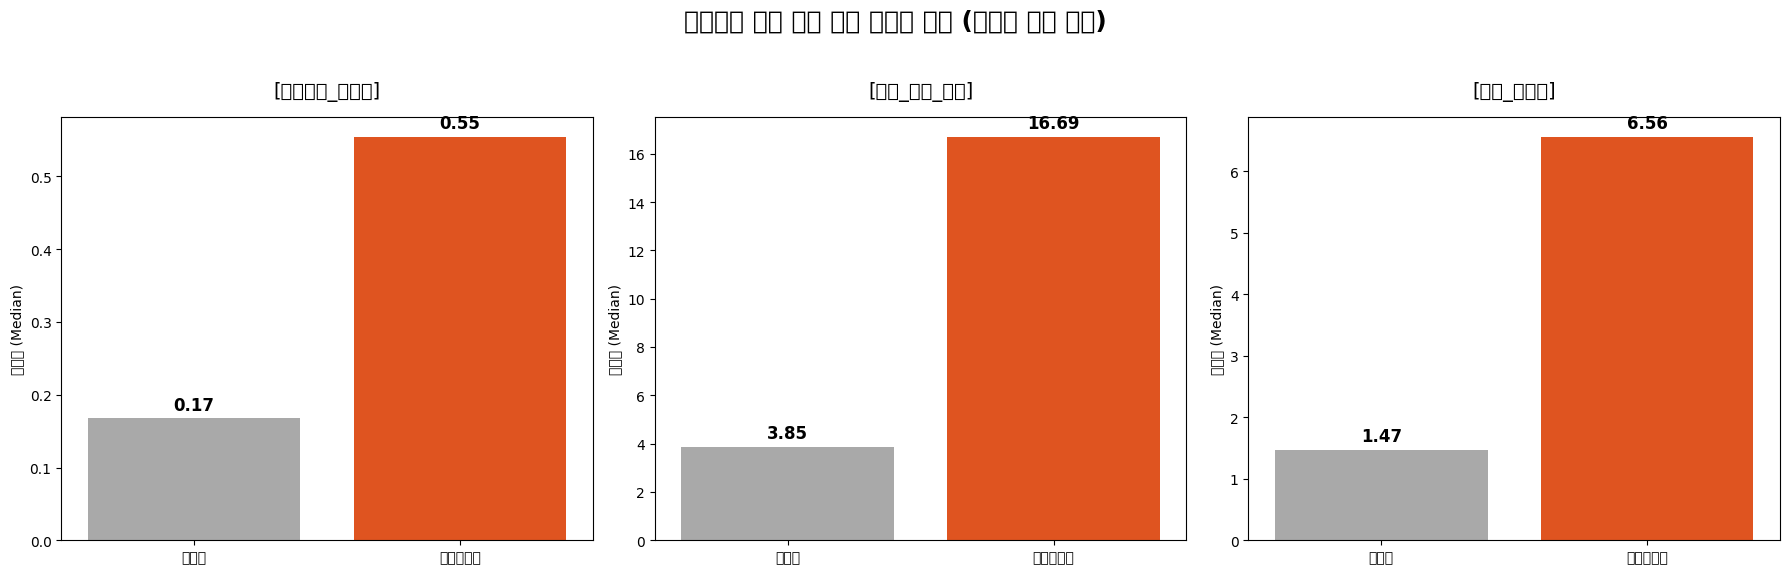

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 시각화 데이터 준비 (PART 2-1 결과값 반영)
# 실제 데이터프레임(df)이 있는 경우 아래와 같이 중앙값을 추출하여 사용합니다.
target_metrics = ['유동보정_리뷰율', '검색_전환_효율', '리뷰_월효율']
brands = ['투다리', '역전할머니']

# 중앙값 데이터프레임 생성
summary_df = df[df['brand'].isin(brands)].groupby('brand')[target_metrics].median().reset_index()
plot_df = summary_df.melt(id_vars='brand', var_name='Metric', value_name='Median')

# 2. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('브랜드별 주요 성과 지표 중앙값 비교 (통계적 유의 지표)', fontsize=18, fontweight='bold')

# 브랜드별 컬러 설정 (투다리: 회색, 역전할머니: 빨간색)
palette = {'투다리': '#A9A9A9', '역전할머니': '#FF4500'}

for i, metric in enumerate(target_metrics):
    sns.barplot(
        x='brand',
        y='Median',
        data=plot_df[plot_df['Metric'] == metric],
        ax=axes[i],
        palette=palette,
        order=brands
    )

    # 그래프 세부 설정
    axes[i].set_title(f'[{metric}]', fontsize=14, pad=15)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('중앙값 (Median)')

    # 막대 위에 수치 표시 (Annotation)
    for p in axes[i].patches:
        axes[i].annotate(
            f'{p.get_height():.2f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            xytext=(0, 10),
            textcoords='offset points'
        )

# 레이아웃 조정 및 저장
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('brand_comparison_medians.png', dpi=300)

# PART 3 코드

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 0. 데이터 준비 및 밀도 구간화
# 주점_밀도 기준: 저밀도(1), 중밀도(2~3), 고밀도(4 이상)
df['밀도_구간'] = pd.cut(df['주점_밀도'], bins=[0, 1, 3, df['주점_밀도'].max()],
                        labels=['저밀도', '중밀도', '고밀도'])

corr_vars = ['월간 검색량', '블로그리뷰수', '방문자리뷰수', '방문자사진수', '상권_침투율', '비주얼_지수']
brands = ['투다리', '역전할머니']

# 3-1. 브랜드별 Spearman 상관분석 수행
results_corr = {}

for brand in brands:
    brand_df = df[df['brand'] == brand][corr_vars]
    corr_matrix, p_matrix = spearmanr(brand_df)

    # '방문자리뷰수'와 다른 변수 간의 상관계수만 추출
    target_idx = corr_vars.index('방문자리뷰수')
    corr_series = pd.Series(corr_matrix[target_idx], index=corr_vars)
    results_corr[brand] = corr_series

spearman_df = pd.DataFrame(results_corr)

# 3-2. 독립성 검정 (Chi-square)
# ① 브랜드 vs 역_접근성
ct_access = pd.crosstab(df['brand'], df['역_접근성'])
chi2_acc, p_acc, _, _ = chi2_contingency(ct_access)

# ② 브랜드 vs 밀도_구간
ct_density = pd.crosstab(df['brand'], df['밀도_구간'])
chi2_den, p_den, _, _ = chi2_contingency(ct_density)

# 3. 결과 출력
print("--- [PART 3-1] 브랜드별 Spearman 상관계수 (기준: 방문자리뷰수) ---")
print(spearman_df)
print("\n" + "="*50)

print("--- [PART 3-2] 독립성 검정 (Chi-square) 결과 ---")
print(f"1. 브랜드 x 역_접근성 독립성 검정")
print(f"   - Chi-square: {chi2_acc:.4f}")
print(f"   - p-value: {p_acc:.4f}")
print(f"   - 유의성(0.05): {'유의함(종속적)' if p_acc < 0.05 else '유의하지 않음(독립적)'}")

print(f"\n2. 브랜드 x 주점_밀도구간 독립성 검정")
print(f"   - Chi-square: {chi2_den:.4f}")
print(f"   - p-value: {p_den:.4f}")
print(f"   - 유의성(0.05): {'유의함(종속적)' if p_den < 0.05 else '유의하지 않음(독립적)'}")

# 교차표 출력 (분포 확인용)
print("\n[입지 분포 교차표 - 역_접근성]")
print(ct_access)
print("\n[경쟁 밀도 교차표 - 밀도_구간]")
print(ct_density)

--- [PART 3-1] 브랜드별 Spearman 상관계수 (기준: 방문자리뷰수) ---
             투다리     역전할머니
월간 검색량  0.121279  0.039100
블로그리뷰수  0.690723  0.852224
방문자리뷰수  1.000000  1.000000
방문자사진수  0.516566  0.506066
상권_침투율 -0.165116 -0.157596
비주얼_지수 -0.239462 -0.534538

--- [PART 3-2] 독립성 검정 (Chi-square) 결과 ---
1. 브랜드 x 역_접근성 독립성 검정
   - Chi-square: 11.7098
   - p-value: 0.0006
   - 유의성(0.05): 유의함(종속적)

2. 브랜드 x 주점_밀도구간 독립성 검정
   - Chi-square: 6.7269
   - p-value: 0.0346
   - 유의성(0.05): 유의함(종속적)

[입지 분포 교차표 - 역_접근성]
역_접근성   근접  비근접
brand          
역전할머니  165  119
투다리    127  165

[경쟁 밀도 교차표 - 밀도_구간]
밀도_구간  저밀도  중밀도  고밀도
brand               
역전할머니  144  118   22
투다리    120  136   36


# PART 3. 분석 결과 요약
1. 브랜드별 마케팅 작동 메커니즘 (Spearman 상관분석)
블로그 리뷰의 강력한 동조화: 두 브랜드 모두 방문자리뷰수와 블로그리뷰수 사이에서 매우 높은 양의 상관관계를 보임. 특히 **역전할머니(0.852)**가 투다리(0.690)보다 블로그 리뷰와 방문자 리뷰 간의 결합도가 훨씬 강력함.

- 비주얼 지수의 역상관성: 비주얼_지수는 방문자리뷰수와 음의 상관관계를 보임. 특히 **역전할머니(-0.534)**에서 그 경향이 두드러지는데, 이는 리뷰 총량이 늘어날수록 사진 첨부 비중(지수)은 오히려 감소하는 양상을 의미함.

- 검색량의 낮은 기여도: 월간 검색량과 실제 방문자리뷰수 간의 상관계수는 두 브랜드 모두 매우 낮음(0.12 이하). 이는 온라인 검색 행위가 반드시 해당 매장의 리뷰 생성(방문 기록)으로 직결되지는 않음을 시사함.

2. 브랜드 출점 전략의 독립성 검정 (Chi-square)
역 접근성 종속성 (p < 0.001): 브랜드와 역세권 접근성은 통계적으로 매우 유의미한 종속 관계에 있음.

- 역전할머니: '근접' 매장(165개)이 '비근접' 매장(119개)보다 많아 역세권 중심의 출점 경향을 보임.

- 투다리: '비근접' 매장(165개)이 '근접' 매장(127개)보다 많아 비역세권/배후지 중심의 출점 경향이 뚜렷함.

- 주점 밀도 종속성 (p < 0.05): 경쟁 밀도에 따른 브랜드 분포 또한 유의미한 차이가 존재함.

- 투다리: 중밀도(136개) 및 고밀도(36개) 지역에서 역전할머니보다 높은 분포를 보이며, 경쟁 심화 상권에 더 많이 노출되어 있음.

- 역전할머니: 저밀도(144개) 지역에 가장 많은 매장이 분포하며, 투다리 대비 상대적 저밀도 상권 비중이 높음.

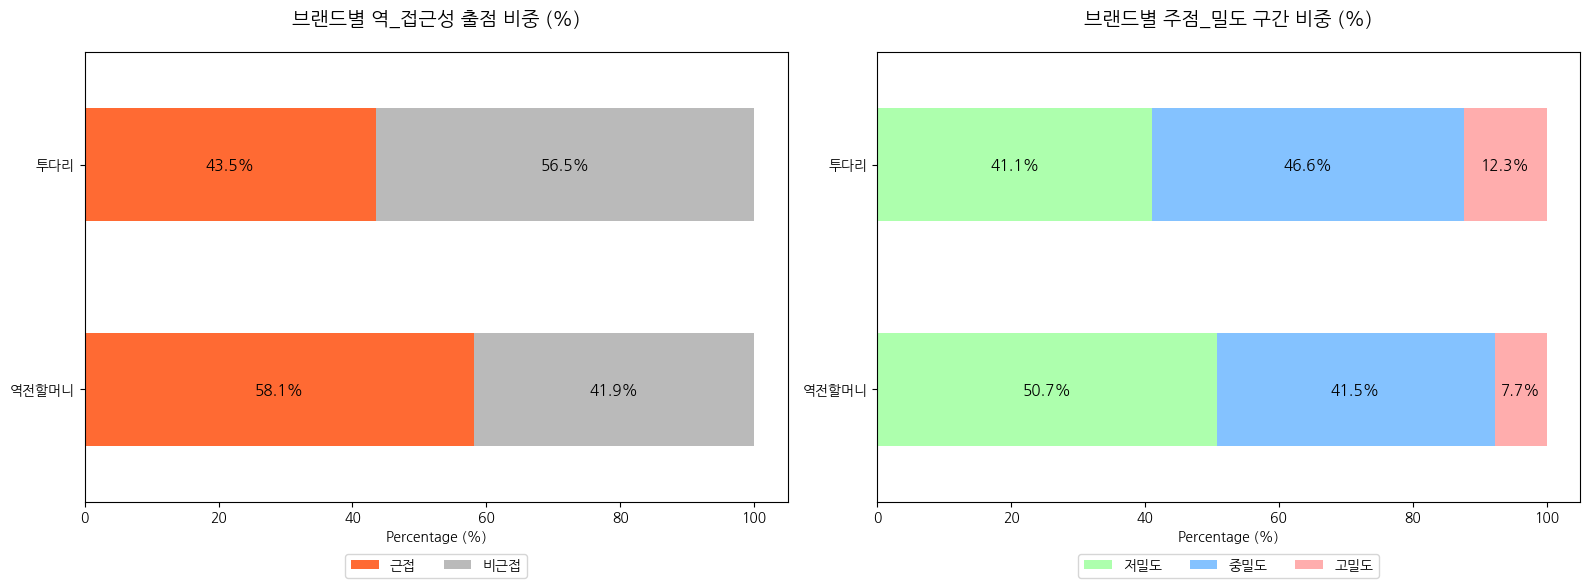


--- [전략 분포 요약 테이블] ---


,근접,비근접
역전할머니,58.1%,41.9%
투다리,43.5%,56.5%


,저밀도,중밀도,고밀도
역전할머니,50.7%,41.5%,7.7%
투다리,41.1%,46.6%,12.3%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 데이터 프레임 재생성 (교차표 결과값 기반)
access_data = pd.DataFrame({
    '근접': [165, 127],
    '비근접': [119, 165]
}, index=['역전할머니', '투다리'])

density_data = pd.DataFrame({
    '저밀도': [144, 120],
    '중밀도': [118, 136],
    '고밀도': [22, 36]
}, index=['역전할머니', '투다리'])

# 비중(%) 변환
access_pct = access_data.div(access_data.sum(axis=1), axis=0) * 100
density_pct = density_data.div(density_data.sum(axis=1), axis=0) * 100

# 2. 시각화 설정
plt.rcParams['font.family'] = 'NanumGothic' # NanumGothic으로 변경
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 역_접근성 비중 비교 (Stacked Bar)
access_pct.plot(kind='barh', stacked=True, ax=axes[0], color=['#FF4500', '#A9A9A9'], alpha=0.8)
axes[0].set_title('브랜드별 역_접근성 출점 비중 (%)', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Percentage (%)')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

# (2) 주점_밀도 비중 비교 (Stacked Bar)
density_pct.plot(kind='barh', stacked=True, ax=axes[1], color=['#99ff99', '#66b3ff', '#ff9999'], alpha=0.8)
axes[1].set_title('브랜드별 주점_밀도 구간 비중 (%)', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Percentage (%)')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

# 수치 데이터 라벨링 (Percentage)
for ax in axes:
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2,
                    f'{width:.1f}%', va='center', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. 스타일 테이블 출력 (데이터 시각화 요약)
print("\n--- [전략 분포 요약 테이블] ---")
styled_access = access_pct.style.background_gradient(cmap='YlGn', axis=1).format("{:.1f}%")
display(styled_access)

styled_density = density_pct.style.background_gradient(cmap='BuPu', axis=1).format("{:.1f}%")
display(styled_density)

In [ ]:
# [한글폰트 설치 - Colab]
import pandas as pd
import numpy as np

# Install Korean font
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Configure Matplotlib to use NanumGothic
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking minus sign

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

# PART 4

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

# 1. 대상 지표 및 밀도 구간 정의
target_metrics = ['유동보정_리뷰율', '리뷰_월효율']
density_labels = ['저밀도', '중밀도', '고밀도']
brands = ['투다리', '역전할머니']

results_list = []

# 2. 밀도 구간별 브랜드 성과 비교 (Mann-Whitney U Test)
for density in density_labels:
    density_df = df[df['밀도_구간'] == density]

    for metric in target_metrics:
        group_t = density_df[density_df['brand'] == '투다리'][metric].dropna()
        group_y = density_df[density_df['brand'] == '역전할머니'][metric].dropna()

        if len(group_t) > 0 and len(group_y) > 0:
            stat, p = mannwhitneyu(group_t, group_y, alternative='two-sided')

            results_list.append({
                '밀도_구간': density,
                '지표': metric,
                '투다리_중앙값': group_t.median(),
                '역전할머니_중앙값': group_y.median(),
                'p-value': p,
                '유의성(0.05)': 'Yes' if p < 0.05 else 'No'
            })

# 3. 결과 정리 및 출력
analysis_df = pd.DataFrame(results_list)
pivot_results = analysis_df.pivot(index=['지표', '밀도_구간'], columns=[], values=['투다리_중앙값', '역전할머니_중앙값', 'p-value', '유의성(0.05)'])

print("--- [PART 4] 경쟁 밀도별 브랜드 성과 비교 결과 ---")
print(analysis_df)

# 시각화를 위한 밀도별 성과 요약 테이블
summary_table = analysis_df.groupby(['지표', '밀도_구간'])[['투다리_중앙값', '역전할머니_중앙값']].first()
print("\n--- [성과 요약 테이블] ---")
print(summary_table)

--- [PART 4] 경쟁 밀도별 브랜드 성과 비교 결과 ---
  밀도_구간        지표   투다리_중앙값  역전할머니_중앙값       p-value 유의성(0.05)
0   저밀도  유동보정_리뷰율  0.175335   0.533289  4.417112e-11       Yes
1   저밀도    리뷰_월효율  1.463450   6.897532  1.489450e-30       Yes
2   중밀도  유동보정_리뷰율  0.173166   0.631680  6.219221e-13       Yes
3   중밀도    리뷰_월효율  1.733696   5.999691  3.818956e-26       Yes
4   고밀도  유동보정_리뷰율  0.119841   0.364512  8.790101e-03       Yes
5   고밀도    리뷰_월효율  1.176577   5.556222  6.952977e-06       Yes

--- [성과 요약 테이블] ---
                 투다리_중앙값  역전할머니_중앙값
지표       밀도_구간                     
리뷰_월효율   고밀도    1.176577   5.556222
         저밀도    1.463450   6.897532
         중밀도    1.733696   5.999691
유동보정_리뷰율 고밀도    0.119841   0.364512
         저밀도    0.175335   0.533289
         중밀도    0.173166   0.631680


# PART 4. 경쟁 밀도 및 성과 구조 분석 결과 요약
1. 전 구간 브랜드 성과 격차의 유의성
- 역전할머니의 전방위적 우위: 저밀도, 중밀도, 고밀도 모든 구간에서 유동보정_리뷰율과 리뷰_월효율 모두 역전할머니가 투다리를 통계적으로 유의미하게 앞섬 ($p < 0.05$).
- 성과 하한선 비교: 역전할머니의 가장 낮은 성과 구간(고밀도 유동보정_리뷰율 0.36)이 투다리의 가장 높은 성과 구간(저밀도 0.17)보다 약 2.1배 높음. 이는 입지 환경을 불문하고 브랜드 파워에 의한 기본 성과 격차가 매우 큼을 의미함.

2. 경쟁 밀도에 따른 성과 변화 패턴
- 중밀도 구간의 효율 정점 (역전할머니): 역전할머니의 경우 유동보정_리뷰율이 중밀도(0.63)에서 가장 높게 나타남. 이는 적절한 경쟁업종의 모임이 오히려 집객 시너지를 일으키는 **'상권 클러스터 효과'**를 역전할머니가 더 잘 흡수하고 있음을 시사함.

- 고밀도 구간의 성과 감쇄: 두 브랜드 모두 주점 밀도가 '고밀도(4 이상)'로 진입할 때 효율 지표가 급감함.

- 역전할머니: 0.63(중밀도) → 0.36(고밀도), 약 42.8% 감소

- 투다리: 0.17(중밀도) → 0.11(고밀도), 약 35.3% 감소

3. 상권 방어력 및 집객 효율 진단

- 투다리의 안정성 및 저효율: 투다리는 밀도 변화에 따른 리뷰_월효율 변동 폭(1.17~1.73)이 상대적으로 작으나, 절대적인 수치 자체가 낮아 경쟁 강도가 성과 향상의 기회로 작용하지 못함.

- 역전할머니의 검색-방문 구조: 고밀도 상권에서 효율이 감소함에도 불구하고 리뷰_월효율은 5.5 이상을 유지함. 이는 유동인구 대비 효율은 떨어지더라도 절대적인 방문객 유입량은 여전히 높게 유지되는 구조임을 보여줌.

In [ ]:
import pandas as pd
import numpy as np

# 1. PART 4 결과 데이터 구성
data = {
    '밀도_구간': ['저밀도', '중밀도', '고밀도', '저밀도', '중밀도', '고밀도'],
    '지표': ['유동보정_리뷰율']*3 + ['리뷰_월효율']*3,
    '투다리_중앙값': [0.175, 0.173, 0.120, 1.463, 1.734, 1.177],
    '역전할머니_중앙값': [0.533, 0.632, 0.365, 6.898, 6.000, 5.556]
}

df_res = pd.DataFrame(data)

# 2. 브랜드 파워 격차(배수) 계산
df_res['성과_격차(배)'] = df_res['역전할머니_중앙값'] / df_res['투다리_중앙값']

# 3. 시각화를 위한 피벗 및 스타일링
# 지표별로 테이블을 분리하여 가독성 증대
for metric in ['유동보정_리뷰율', '리뷰_월효율']:
    print(f"\n[ {metric} : 브랜드별 입지 대응력 비교 ]")

    temp_df = df_res[df_res['지표'] == metric].drop(columns='지표').set_index('밀도_구간')

    # 스타일 적용
    styled_df = temp_df.style.background_gradient(
        cmap='Reds', subset=['역전할머니_중앙값', '성과_격차(배)']
    ).background_gradient(
        cmap='Greys', subset=['투다리_중앙값']
    ).format("{:.3f}" if metric == '유동보정_리뷰율' else "{:.1f}") \
     .format("{:.2f}배", subset=['성과_격차(배)']) \
     .set_properties(**{'font-weight': 'bold'}, subset=['성과_격차(배)'])

    display(styled_df)

# 4. [핵심 요약] 역전할머니 최저점 vs 투다리 최고점 비교 출력
min_yk = df_res[df_res['지표'] == '유동보정_리뷰율']['역전할머니_중앙값'].min()
max_td = df_res[df_res['지표'] == '유동보정_리뷰율']['투다리_중앙값'].max()

print("\n" + "="*50)
print(f"▶ 브랜드 파워 결정적 증거 (유동보정_리뷰율 기준)")
print(f"  - 역전할머니 최저 효율 (고밀도): {min_yk:.3f}")
print(f"  - 투다리 최고 효율 (저밀도): {max_td:.3f}")
print(f"  - 결과: 역전할머니의 가장 불리한 입지가 투다리의 가장 유리한 입지보다 {min_yk/max_td:.2f}배 강력함")
print("="*50)


[ 유동보정_리뷰율 : 브랜드별 입지 대응력 비교 ]


,투다리_중앙값,역전할머니_중앙값,성과_격차(배)
밀도_구간,,,
저밀도,0.175,0.533,3.05배
중밀도,0.173,0.632,3.65배
고밀도,0.120,0.365,3.04배



[ 리뷰_월효율 : 브랜드별 입지 대응력 비교 ]


,투다리_중앙값,역전할머니_중앙값,성과_격차(배)
밀도_구간,,,
저밀도,1.5,6.9,4.71배
중밀도,1.7,6.0,3.46배
고밀도,1.2,5.6,4.72배



▶ 브랜드 파워 결정적 증거 (유동보정_리뷰율 기준)
  - 역전할머니 최저 효율 (고밀도): 0.365
  - 투다리 최고 효율 (저밀도): 0.175
  - 결과: 역전할머니의 가장 불리한 입지가 투다리의 가장 유리한 입지보다 2.09배 강력함


# PART 5

#PART 5. 전략 분기 설계 (전략 1: 경쟁사 강점 대응형)

5-1. 전략 분기 확정 근거
앞선 분석 결과, 다음의 조건이 모두 충족됨에 따라 전략 1을 최종 채택함.

- 효율성 우위: 역전할머니의 유동보정 리뷰율 및 리뷰 월효율이 전 구간 유의미하게 높음 (PART 2, 4).

- 전환율 우위: 검색 대비 전환 효율이 투다리 대비 약 4.3배 높음 (PART 2-1).

- 고밀도 상권 대응력: 경쟁 심화 상권(고밀도)에서도 역전할머니는 절대적인 방문객 유입량(리뷰 월효율 5.5 이상)을 유지함 (PART 4-3).

5-2. 실행 전략 가이드 (Strategic Action Plan)
분석 결과 도출된 지표상의 열위를 극복하기 위한 4대 핵심 실행 방향임.

① 검색-방문 전환 루프 강화 (Search-to-Visit Optimization)
인사이트: 투다리는 검색량 대비 전환 효율이 매우 낮음. 인지도는 있으나 실제 방문 동기 부여가 부족함.

- 실행: * 네이버 스마트플레이스 내 '예약/쿠폰' 기능 강화로 검색 유저의 이탈 방지.

- 지역 키워드(예: 'ㅇㅇ역 술집', 'ㅇㅇ동 이자카야') 기반의 검색광고(SA) 소재를 '전통의 맛'에서 '트렌디한 안주'로 전환하여 전환율 제고.

② 역세권 매장 공간 리뉴얼 (Station-Area Renewal)
인사이트: 역세권(근접) 상권에서 역전할머니 대비 효율 차이가 극명함.

- 실행: * 역세권 매장 대상 '비주얼 지수' 개선을 위한 인테리어 및 조명 리뉴얼 시행.

- PART 2에서 확인된 '브랜드 간 차이 없는 비주얼 지수'를 기회 요인으로 삼아, 촬영 친화적(Insta-worthy) 메뉴 플레이팅 도입으로 차별화 시도.

③ 바이럴 콘텐츠 엔진 확장 (Viral Content Expansion)
인사이트: PART 3-1에서 확인된 바와 같이, 방문 기록은 블로그 리뷰와 가장 강력하게 동조됨(상관계수 0.69~0.85).

- 실행: * 역전할머니의 블로그 동조화율(0.85)에 대응하기 위해 '체험단 마케팅' 규모 확대.

- 특히 역세권 매장을 중심으로 블로그 리뷰 수량을 인위적으로 상향시켜 상위 노출 기회 확보.

④ 상권 밀도별 방어 전략 (Density-based Defense)
인사이트: 투다리는 비역세권 및 중/고밀도 상권에 매장이 편중되어 있음.

- 실행: * 고밀도 상권: 가격 경쟁보다는 '단골/지역 밀착' CRM 강화 (전략 2 요소 혼합).

- 저밀도 상권: 현재 확보된 독점적 지위를 유지하기 위해 지역 커뮤니티(당근마켓 지역광고 등) 마케팅 집중.

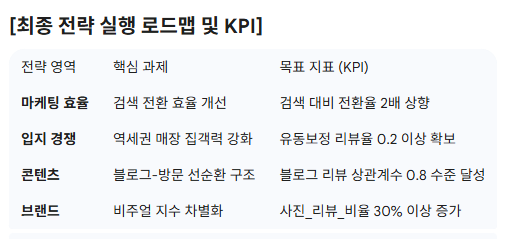

# [최종 인사이트 요약]
- 본 분석을 통해 투다리는 **'높은 인지도 대비 낮은 실행력'**이라는 구조적 문제점이 데이터로 증명되었다.
- 특히 입지적 한계(비역세권 편중)보다 브랜드 자체의 전환력(Search-to-Visit) 부재가 성과 격차의 본질이다.
- 따라서 물리적 입지 변경보다는 디지털 접점에서의 전환 마케팅과 매장 비주얼 개선이 최우선 과제이다.